In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

In [94]:
# 加载数据集
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\further_cleaned_dataset.csv")
df.head(10)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Age,Miles_per_year,Brand_Model
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005,6,Automatic,4x4,4,Left wheel,Silver,12,15,12400.333333,LEXUS_RX 450
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,6,Tiptronic,4x4,4,Left wheel,Black,8,14,13714.285714,CHEVROLET_Equinox
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,4,Variator,Front,4,Right-hand drive,Black,2,19,10526.315789,HONDA_FIT
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,4,Automatic,4x4,4,Left wheel,White,0,14,12069.000000,FORD_Escape
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,4,Automatic,Front,4,Left wheel,Silver,4,11,8354.636364,HONDA_FIT
5,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931,4,Automatic,Front,4,Left wheel,White,4,9,17881.222222,HYUNDAI_Santa FE
6,1803,761.0,TOYOTA,Prius,2010,Hatchback,1,Hybrid,1.8,258909,4,Automatic,Front,4,Left wheel,White,12,15,17260.600000,TOYOTA_Prius
7,549,751.0,HYUNDAI,Sonata,2013,Sedan,1,Petrol,2.4,216118,4,Automatic,Front,4,Left wheel,Grey,12,12,18009.833333,HYUNDAI_Sonata
8,1098,394.0,TOYOTA,Camry,2014,Sedan,1,Hybrid,2.5,398069,4,Automatic,Front,4,Left wheel,Black,12,11,36188.090909,TOYOTA_Camry
9,26657,NaN,LEXUS,RX 350,2007,Jeep,1,Petrol,3.5,128500,6,Automatic,4x4,4,Left wheel,Silver,12,18,7138.888889,LEXUS_RX 350


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14681 entries, 0 to 14680
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             14681 non-null  int64  
 1   Levy              10929 non-null  float64
 2   Manufacturer      14681 non-null  object 
 3   Model             14681 non-null  object 
 4   Prod. year        14681 non-null  int64  
 5   Category          14681 non-null  object 
 6   Leather interior  14681 non-null  int64  
 7   Fuel type         14681 non-null  object 
 8   Engine volume     14681 non-null  float64
 9   Mileage           14681 non-null  int64  
 10  Cylinders         14681 non-null  int64  
 11  Gear box type     14681 non-null  object 
 12  Drive wheels      14681 non-null  object 
 13  Doors             14681 non-null  int64  
 14  Wheel             14681 non-null  object 
 15  Color             14681 non-null  object 
 16  Airbags           14681 non-null  int64 

In [96]:
# 划分特征与目标变量
X = df.drop('Price', axis=1)
y = np.log1p(df['Price'])  # 对价格取对数处理改善正态分布

In [97]:
# 定义特征类型
categorical_features = ['Manufacturer', 'Model', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']
numeric_features = ['Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Levy', 'Doors', 'Age', 'Miles_per_year']

In [98]:
from sklearn.preprocessing import TargetEncoder

# 创建预处理管道
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

# 分类特征编码改用目标编码（避免维度爆炸）
# preprocessor = ColumnTransformer([
#     ('num', StandardScaler(), ['Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Age', 'Miles_per_year']),
#     ('cat', TargetEncoder(target_type='continuous'), ['Brand_Model', 'Category', 'Fuel type', 'Drive wheels'])
# ])

In [99]:
# X_processed = preprocessor.fit_transform(X)
# mi = mutual_info_regression(X_processed, y)
# selected_features = np.where(mi > 0.01)[0]

In [100]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# 更新模型管道，将特征选择整合到Pipeline中
# model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('feature_selector', SelectKBest(
#         score_func=mutual_info_regression, 
#         k=800  # 根据实际情况调整，需小于预处理后的总特征数
#     )),
#     ('regressor', LinearRegression())
# ])

# 使用树模型捕捉非线性关系
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200, 
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [102]:
# 训练模型
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Prod. year',
                                                   'Engine volume', 'Mileage',
                                                   'Cylinders', 'Airbags',
                                                   'Levy', 'Doors', 'Age',
                                                   'Miles_per_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Manufacturer', 'Model',
                                                   'Category', 'Fuel type',
                                                   'Gear box type',
                                                   'Drive wheels', 'Wheel',
                                                   'Color'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       n_estimators=200, random_state=42))])

In [103]:
# 评估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return {
        'RMSE': np.sqrt(mse),
        'R²': r2,
        'Adjusted R²': 1 - (1 - r2)*(len(y)-1)/(len(y)-X.shape[1]-1)
    }

In [104]:
train_metrics = evaluate_model(model, X_train, y_train)
test_metrics = evaluate_model(model, X_test, y_test)

In [105]:
# 打印结果
print(f"Train Metrics: {train_metrics}")
print(f"Test Metrics: {test_metrics}")

Train Metrics: {'RMSE': np.float64(0.9756669453945498), 'R²': 0.6512154772274676, 'Adjusted R²': 0.6506502344832952}
Test Metrics: {'RMSE': np.float64(1.0571432850790827), 'R²': 0.5609140423857042, 'Adjusted R²': 0.5580540378623338}


In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

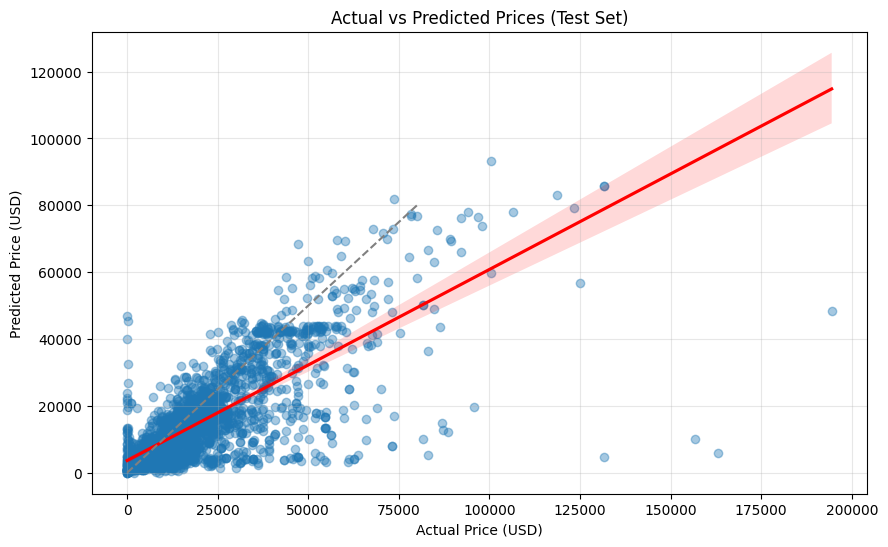

In [ ]:
# 预测值-真实值散点图
plt.figure(figsize=(10, 6))
sns.regplot(x=np.expm1(y_test), y=np.expm1(model.predict(X_test)), 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.plot([0, 80000], [0, 80000], '--', color='gray')  # 对角线参考线
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted Prices (Test Set)')
plt.grid(alpha=0.3)
plt.show()

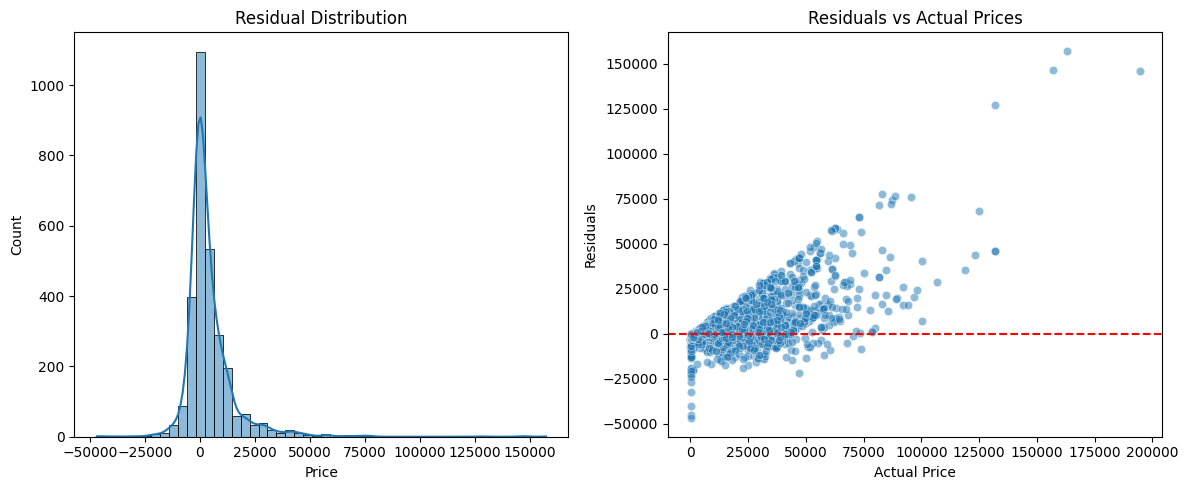

In [108]:
# 残差分布图：验证残差是否符合正态分布假设，检查异方差性
residuals = np.expm1(y_test) - np.expm1(model.predict(X_test))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, bins=50)
plt.title('Residual Distribution')

plt.subplot(1, 2, 2)
sns.scatterplot(x=np.expm1(y_test), y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Actual Prices')
plt.tight_layout()